In [1]:
import earthaccess
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter

In [3]:
path = "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L2_CLOUD_GPC_v3_0/PACE_HARP2.20250706T192050.L2.CLOUD_GPC.V3_0.nc"
ds = xr.open_dataset(path, group='geophysical_data')

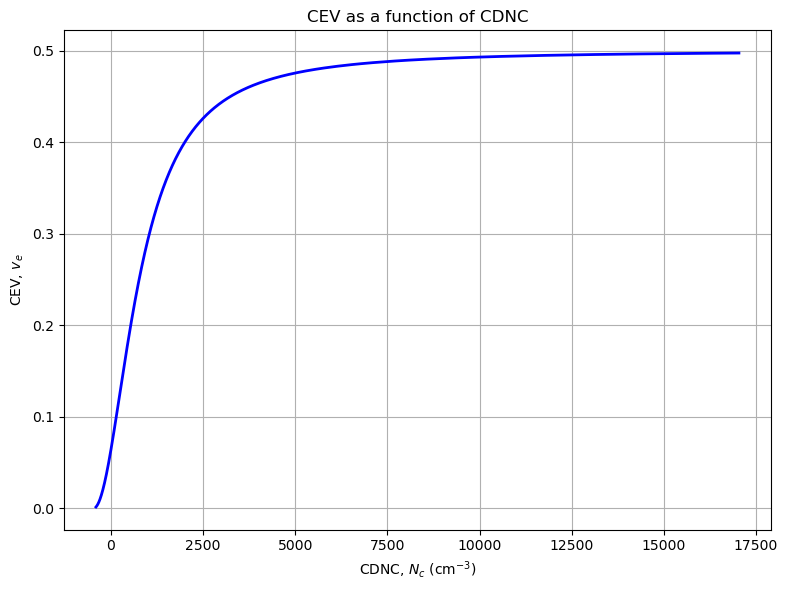

In [4]:
ve = ds['cloud_bow_droplet_effective_variance'].values.flatten()
Nc = (np.sqrt(ve / (1 - 2 * ve)) - 0.2714) / (5.71e-4)

# mask = (ve > 0) & (Nc > 0)
# ve = ve[mask]
# Nc = Nc[mask]

# Sort for a clean curve
idx = np.argsort(Nc)
Nc, ve = Nc[idx], ve[idx]

plt.figure(figsize=(8, 6))
plt.plot(Nc, ve, 'b-', linewidth=2)
plt.xlabel('CDNC, $N_c$ (cm$^{-3}$)')
plt.ylabel('CEV, $v_e$')
# plt.xlim([0, 2000])
# plt.ylim([0, 0.3])
plt.title('CEV as a function of CDNC')
plt.grid(True)
plt.tight_layout()
plt.show()

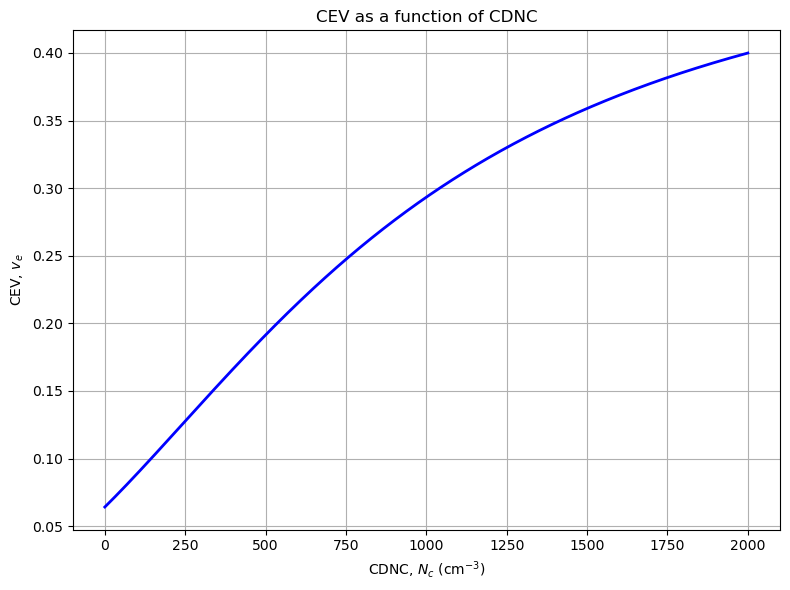

In [5]:
# Define Nc range (typical CDNC range)
Nc = np.linspace(0, 2000, 500)

# Compute ve using the Morrison & Gettelman parameterization
s = 5.71e-4 * Nc + 0.2714
ve = (s**2) / (1 + 2 * s**2)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(Nc, ve, 'b-', linewidth=2)
plt.xlabel('CDNC, $N_c$ (cm$^{-3}$)')
plt.ylabel('CEV, $v_e$')
plt.title('CEV as a function of CDNC')
plt.grid(True)
plt.tight_layout()
plt.show()

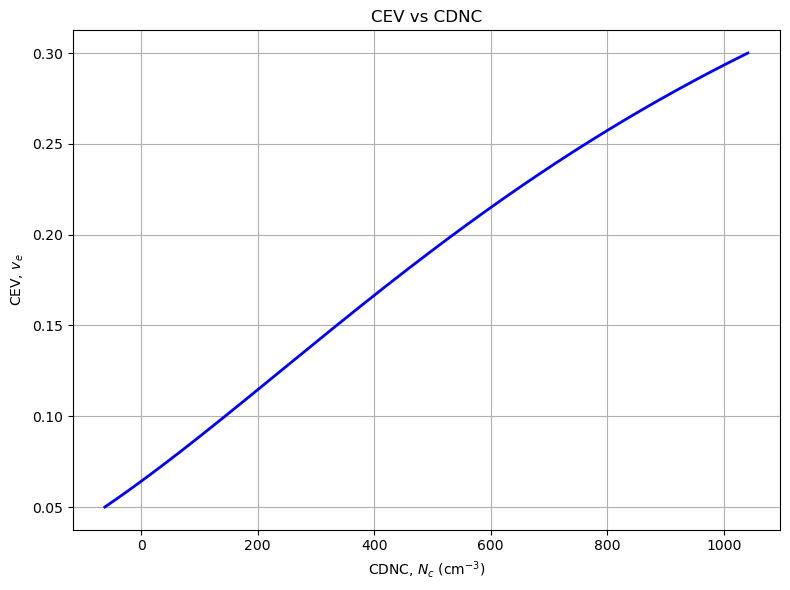

In [6]:
# ve range
ve = np.linspace(0.05, 0.3, 500)

# compute Nc
Nc = (np.sqrt(ve / (1 - 2 * ve)) - 0.2714) / (5.71e-4)

plt.figure(figsize=(8, 6))
plt.plot(Nc, ve, 'b-', linewidth=2)
plt.xlabel('CDNC, $N_c$ (cm$^{-3}$)')
plt.ylabel('CEV, $v_e$')
plt.title('CEV vs CDNC')
plt.grid(True)
plt.tight_layout()
plt.show()